# Genre and Audio Analysis  
## Beatport Tracks + Spotify Audio Features

This notebook explores how musical characteristics vary across electronic music genres.

Main objectives:

- Analyze the distribution of genres in the dataset
- Compare audio features across genres
- Identify stylistic differences between major electronic music categories
- Build genre-level insights from the integrated analytical dataset

In [2]:
# Import core libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Display all columns when inspecting dataframes
pd.set_option("display.max_columns", None)

In [3]:
# Define project data path

processed_path = "../data/processed/"

# Load the processed analytical dataset

tracks_dataset = pd.read_csv(
    processed_path + "electronic_music_tracks_dataset.csv",
    low_memory=False
)

In [4]:
# Inspect dataset shape

print("Dataset shape:", tracks_dataset.shape)

Dataset shape: (4667811, 21)


In [5]:
# Preview dataset structure

tracks_dataset.head()

,spotify_track_id,track_title,isrc,genre_name,subgenre_name,bpm,duration_min,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,tempo_category,energy_level
0,2XRmx1n48eFSEPp9AFuTtF,Bruxism,AAA201604180,Electronica,Unknown,143.0,5.020433,0.000073,0.318,0.690,0.936,9,0.1150,-8.420,1,0.0644,104,4,0.0785,downtempo,medium
1,4BPpQEbXq8rprnSx8AdFKQ,Many,AAA201604181,Electronica,Unknown,120.0,8.544583,0.171000,0.346,0.903,0.122,2,0.5770,-10.111,1,0.6840,193,4,0.0386,fast,high
2,0PjL0BOdLjnRWaEsvehcpG,Onset,AAA201604182,Electronica,Unknown,140.0,7.358950,0.005550,0.349,0.893,0.900,6,0.0625,-8.171,1,0.4270,104,4,0.0349,downtempo,high
3,05GET0OR7Km6yEabSzbOMj,Onset - J. G. Biberkopf Remix,AAA201604183,Electronica,Unknown,86.0,4.200667,0.099800,0.405,0.832,0.847,4,0.0750,-11.891,0,0.1040,171,3,0.0354,fast,high
4,1pzN7qpm3AqSYggL5Pfpl8,Onset - Imaabs Remix,AAA201604184,Electronica,Unknown,83.0,4.626667,0.013400,0.235,0.466,0.799,0,0.0845,-12.491,1,0.0633,88,3,0.0360,slow,medium


## Dataset Overview

Before starting the analysis, we perform a brief inspection of the processed dataset.

The integrated dataset contains Beatport track metadata combined with Spotify audio features.  
Each row represents a **unique track identified by its ISRC code**.

Key information available in the dataset includes:

- genre and subgenre classifications from Beatport
- musical characteristics extracted from Spotify audio features
- derived variables such as **tempo categories** and **energy levels**

The following steps explore the overall structure of the dataset and begin the exploratory analysis by examining the **distribution of musical genres**.

In [7]:
# Genre distribution

genre_counts = tracks_dataset["genre_name"].value_counts()

print("Number of genres:", genre_counts.shape[0])

genre_counts.head(10)

Number of genres: 32


genre_name
Electronica                     722426
Techno (Peak Time / Driving)    553646
House                           449357
Deep House                      319902
Tech House                      311942
Trap / Wave                     235504
Dance / Electro Pop             215489
Progressive House               211315
Minimal / Deep Tech             188948
Drum & Bass                     188454
Name: count, dtype: int64

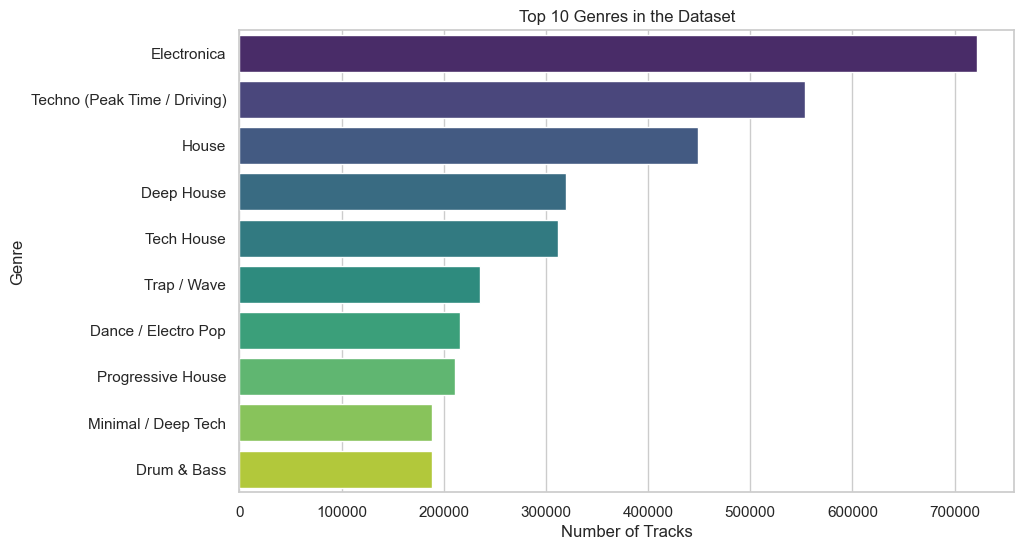

In [8]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Genres in the Dataset")
plt.xlabel("Number of Tracks")
plt.ylabel("Genre")

plt.show()

### Observations

The genre distribution shows a strong concentration of tracks in a few dominant electronic music styles.

Genres such as **Electronica**, **Techno**, **House**, and **Deep House** represent a large proportion of the dataset. This reflects the structure of the Beatport catalog, which is strongly oriented toward club-focused electronic music.

Some genres appear with much smaller representation, including **Amapiano**, **Jackin House**, and certain specialized Trance subcategories.

This uneven distribution should be considered in later analyses, since dominant genres may strongly influence aggregate statistics.

### BPM Adjustment for Half-Time Genres

In some electronic music genres, BPM values may appear in half-time form.

This is particularly common in **Drum & Bass**, where tracks can be labeled around **85–90 BPM** even though they are typically perceived and mixed around **170–180 BPM**.

To make genre-level tempo analysis more meaningful, an adjusted BPM variable is created for genres where half-time tempo detection is common.

The original `bpm` column is preserved, and a new variable called `bpm_adjusted` is used for analysis.

In [11]:
# Create adjusted BPM variable for genres affected by half-time detection

tracks_dataset["bpm_adjusted"] = tracks_dataset["bpm"].copy()

dnb_mask = (
    (tracks_dataset["genre_name"] == "Drum & Bass") &
    (tracks_dataset["bpm_adjusted"] < 110)
)

tracks_dataset.loc[dnb_mask, "bpm_adjusted"] = (
    tracks_dataset.loc[dnb_mask, "bpm_adjusted"] * 2
)

In [12]:
# Compare original and adjusted BPM for Drum & Bass

tracks_dataset.loc[
    tracks_dataset["genre_name"] == "Drum & Bass",
    ["bpm", "bpm_adjusted"]
].describe()

,bpm,bpm_adjusted
count,188323.000000,188323.000000
mean,100.546540,167.735524
std,26.363127,21.033681
min,61.000000,110.000000
25%,87.000000,170.000000
50%,87.000000,174.000000
75%,109.000000,176.000000
max,246.000000,246.000000


### Tempo Characteristics Across Genres

Tempo is one of the most distinctive characteristics in electronic music.

Different genres often follow typical BPM ranges that reflect their stylistic identity and intended use in DJ sets.

For example:

- House music typically ranges between **120–128 BPM**
- Techno often appears around **128–135 BPM**
- Drum & Bass commonly exceeds **170 BPM**

The following analysis explores how tempo varies across the main genres present in the dataset.

In [14]:
genre_bpm = (
    tracks_dataset
    .groupby("genre_name")["bpm_adjusted"]
    .mean()
    .sort_values(ascending=False)
)

genre_bpm.head(10)

genre_name
Drum & Bass                       167.735524
Hard Techno                       138.604210
Psy-Trance                        130.209313
Trance (Main Floor)               129.957910
Hard Dance / Hardcore             128.943239
Trance (Raw / Deep / Hypnotic)    128.592777
Mainstage                         125.429796
Bass House                        124.729292
Techno (Peak Time / Driving)      124.664103
Techno (Raw / Deep / Hypnotic)    124.321495
Name: bpm_adjusted, dtype: float64

### Average BPM by Genre

To improve readability, the genre-level BPM analysis is split into two separate charts:

- genres with the highest average BPM values
- genres with the lowest average BPM values

This makes it easier to compare stylistic differences across the full set of genres while keeping the labels readable.

In [16]:
# Create a continuous palette for all genres
full_palette = sns.color_palette("magma", n_colors=len(genre_bpm))

# Split palette for top and bottom charts

top_palette = full_palette[:16]
bottom_palette = full_palette[16:]

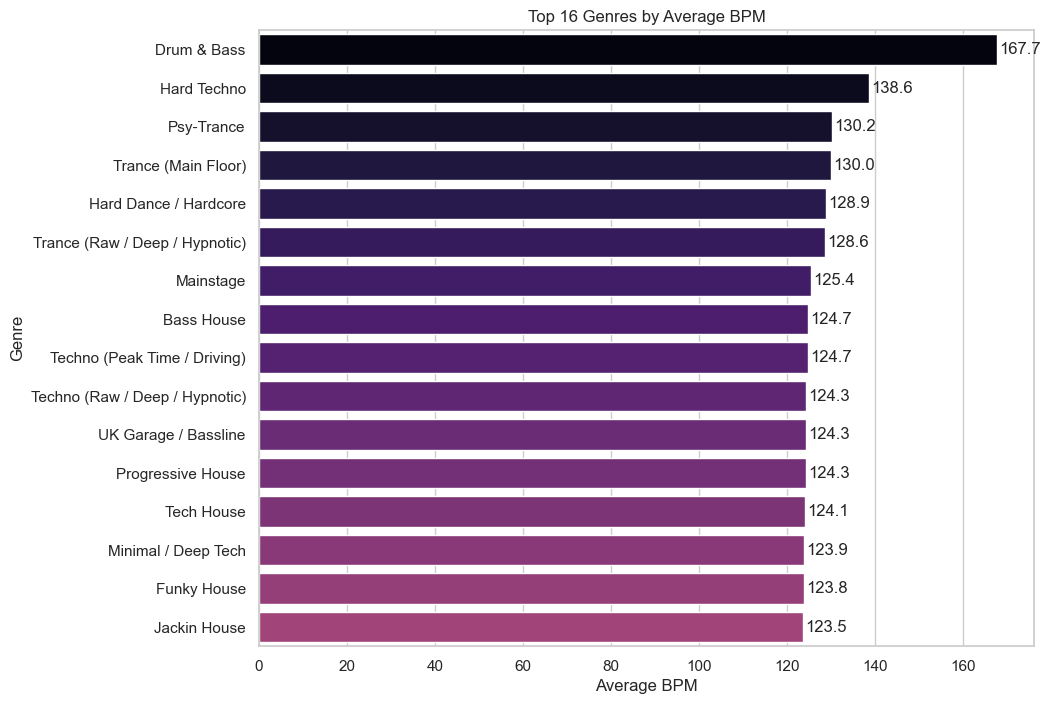

In [17]:
# Select genres with highest average BPM

top_16_bpm = genre_bpm.head(16)

plt.figure(figsize=(10,8))

ax = sns.barplot(
    x=top_16_bpm.values,
    y=top_16_bpm.index,
    hue=top_16_bpm.index,      # <- añadido
    palette=top_palette,
    legend=False               # <- evita leyenda duplicada
)

plt.title("Top 16 Genres by Average BPM")
plt.xlabel("Average BPM")
plt.ylabel("Genre")

for i, value in enumerate(top_16_bpm.values):
    ax.text(value + 0.5, i, f"{value:.1f}", va="center")

plt.show()

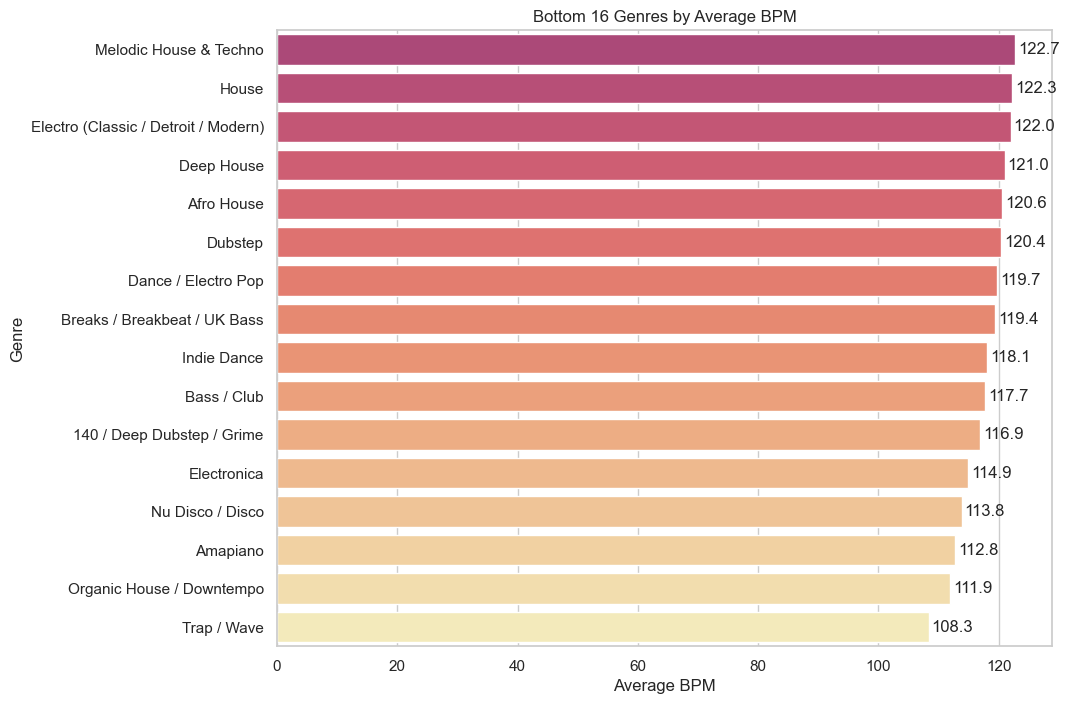

In [18]:
# Select genres with lowest average BPM

bottom_16_bpm = genre_bpm.tail(16).sort_values(ascending=False)

plt.figure(figsize=(10,8))

ax = sns.barplot(
    x=bottom_16_bpm.values,
    y=bottom_16_bpm.index,
    hue=bottom_16_bpm.index,   # <- añadido
    palette=bottom_palette,
    legend=False
)

plt.title("Bottom 16 Genres by Average BPM")
plt.xlabel("Average BPM")
plt.ylabel("Genre")

for i, value in enumerate(bottom_16_bpm.values):
    ax.text(value + 0.5, i, f"{value:.1f}", va="center")

plt.show()

### BPM Distribution Across Major Genres

While average BPM values provide a useful first summary, they do not capture the full distribution of tempo within each genre.

To better understand stylistic variability, the following analysis examines the BPM distribution of the most represented genres in the dataset.

Using boxplots allows us to compare:

- central tendency
- spread
- outliers
- genre-specific tempo consistency

To keep the visualization readable while preserving all observations, the analysis focuses on the **10 most frequent genres** in the dataset.

In [20]:
# Filter full data for the 10 most frequent genres

top_genres_list = genre_counts.head(10).index

genre_bpm_data = tracks_dataset[
    tracks_dataset["genre_name"].isin(top_genres_list)
].copy()

print("Filtered dataset shape:", genre_bpm_data.shape)

Filtered dataset shape: (3396983, 22)


In [21]:
# Order genres by average adjusted BPM

genre_order = (
    genre_bpm_data
    .groupby("genre_name")["bpm_adjusted"]
    .mean()
    .sort_values(ascending=False)
    .index
)

genre_order

Index(['Drum & Bass', 'Techno (Peak Time / Driving)', 'Progressive House',
       'Tech House', 'Minimal / Deep Tech', 'House', 'Deep House',
       'Dance / Electro Pop', 'Electronica', 'Trap / Wave'],
      dtype='object', name='genre_name')

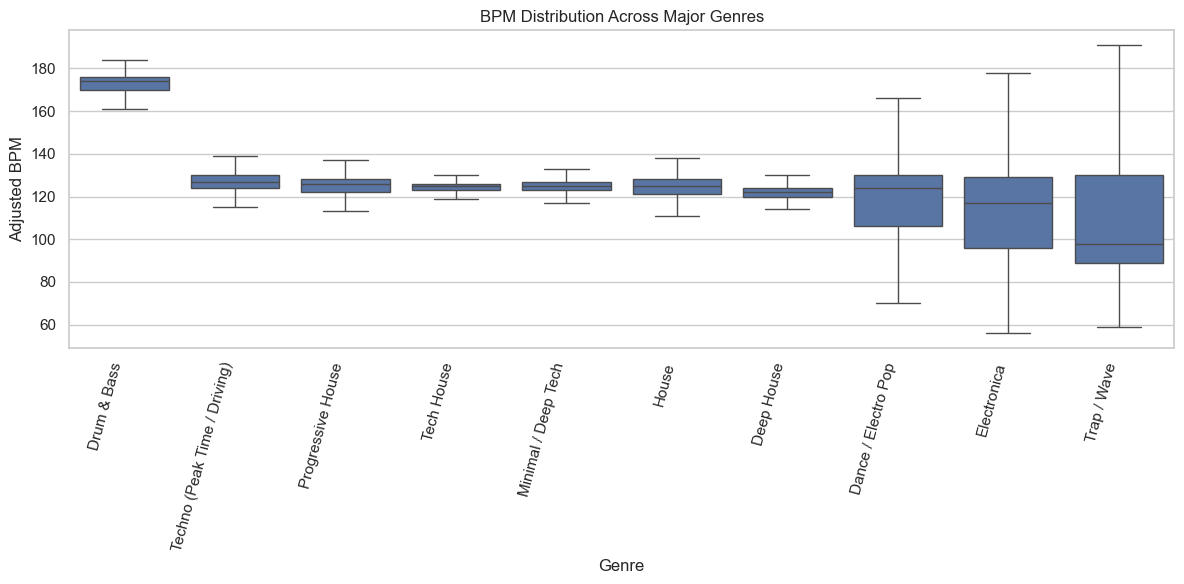

In [22]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=genre_bpm_data,
    x="genre_name",
    y="bpm_adjusted",
    order=genre_order,
    showfliers=False
)

plt.title("BPM Distribution Across Major Genres")
plt.xlabel("Genre")
plt.ylabel("Adjusted BPM")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()
plt.show()

### Observations

The BPM distributions reveal clear tempo conventions across electronic music genres.

**Drum & Bass** shows the most concentrated tempo range, with values tightly clustered around 170–176 BPM. This reflects the strong stylistic convention of the genre.

House-related genres such as **House**, **Deep House**, **Tech House**, and **Minimal / Deep Tech** exhibit very consistent tempo distributions between roughly **120 and 128 BPM**, which corresponds to the typical tempo range used in DJ-oriented club music.

**Techno (Peak Time / Driving)** appears slightly faster, with median values around 128–130 BPM, reflecting the energetic tempo commonly used in modern techno production.

More general categories such as **Electronica** and **Dance / Electro Pop** show wider distributions, indicating greater stylistic diversity.

Finally, **Trap / Wave** presents the largest variability in BPM values. This is likely due to the common use of half-time and double-time rhythmic structures in these genres.

## Energy and Danceability Analysis Across Genres

Two of the most informative musical descriptors provided by Spotify are **energy** and **danceability**.

- **Energy** represents the perceived intensity and activity of a track. High-energy tracks tend to feel fast, loud, and dynamic.
- **Danceability** measures how suitable a track is for dancing, considering elements such as rhythm stability, beat strength, and tempo.

Since the dataset contains **millions of tracks**, analyzing individual observations can lead to highly dense visualizations that are difficult to interpret.  
Instead, we aggregate these audio features **at the genre level** to better capture the typical musical characteristics of each style.

In this section we:

1. Compute the **average energy and danceability for each genre**
2. Identify the genres with the **highest values for each feature**
3. Compare how different electronic music styles position themselves in terms of **intensity and dancefloor orientation**

This approach highlights the stylistic tendencies of electronic music genres while reducing noise from individual tracks.

In [25]:
# Compute average energy and danceability for each genre
genre_features = (
    tracks_dataset
    .groupby("genre_name")[["energy", "danceability"]]
    .mean()
    .sort_values("energy", ascending=False)
)

genre_features.head(10)

,energy,danceability
genre_name,,
Hard Dance / Hardcore,0.913586,0.586912
Hard Techno,0.899713,0.620340
Psy-Trance,0.879697,0.613841
Drum & Bass,0.847064,0.582402
Trance (Raw / Deep / Hypnotic),0.844701,0.625604
Trance (Main Floor),0.841440,0.595579
Funky House,0.824810,0.769886
Jackin House,0.791688,0.800864
Bass House,0.787963,0.786702


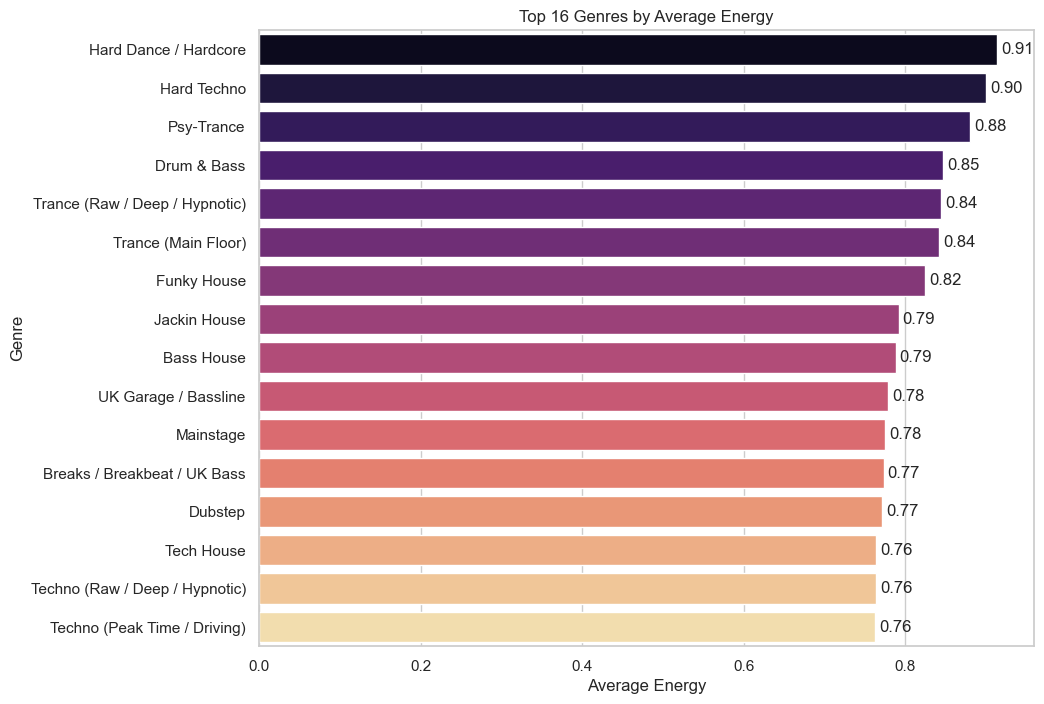

In [26]:
# Select genres with highest average energy

top_energy = genre_features.head(16)

plt.figure(figsize=(10,8))

ax = sns.barplot(
    x=top_energy["energy"],
    y=top_energy.index,
    hue=top_energy.index,
    palette="magma",
    legend=False
)

plt.title("Top 16 Genres by Average Energy")
plt.xlabel("Average Energy")
plt.ylabel("Genre")

for i, value in enumerate(top_energy["energy"]):
    ax.text(value + 0.005, i, f"{value:.2f}", va="center")

plt.show()

### Observations

Genres associated with high-intensity electronic music dominate the top of the ranking.

Styles such as **Hard Dance / Hardcore**, **Hard Techno**, **Psy-Trance**, and **Drum & Bass** exhibit the highest average energy values. These genres are typically characterized by aggressive sound design, dense percussion, and high perceived loudness.

Interestingly, several house subgenres such as **Funky House**, **Jackin House**, and **Bass House** also appear among the most energetic genres. While these styles are primarily designed for dancefloor environments, they still maintain relatively high energy levels compared to other electronic music styles.

Overall, the results confirm that Spotify's **energy feature** effectively captures the perceived intensity of different electronic music genres.

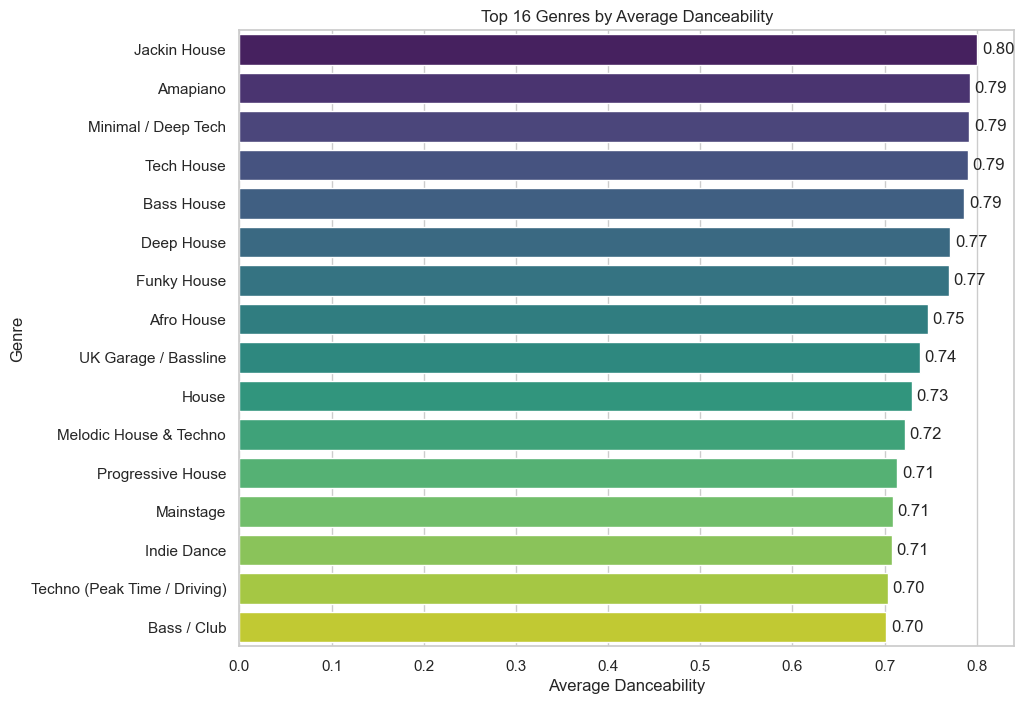

In [28]:
# Select genres with highest average danceability

top_danceability = genre_features.sort_values(
    "danceability",
    ascending=False
).head(16)

plt.figure(figsize=(10,8))

ax = sns.barplot(
    x=top_danceability["danceability"],
    y=top_danceability.index,
    hue=top_danceability.index,
    palette="viridis",
    legend=False
)

plt.title("Top 16 Genres by Average Danceability")
plt.xlabel("Average Danceability")
plt.ylabel("Genre")

for i, value in enumerate(top_danceability["danceability"]):
    ax.text(value + 0.005, i, f"{value:.2f}", va="center")

plt.show()

### Observations

Genres associated with groove-oriented electronic music dominate the top of the danceability ranking.

House-related styles such as **Jackin House**, **Tech House**, **Minimal / Deep Tech**, **Bass House**, and **Deep House** exhibit the highest average danceability values. These genres typically rely on steady rhythms and strong groove structures designed for dancefloor environments.

Interestingly, **Amapiano** also appears among the most danceable genres, reflecting its characteristic rhythmic patterns and percussive groove.

In contrast to the energy ranking, several high-intensity genres such as **Hard Techno**, **Hard Dance / Hardcore**, and **Drum & Bass** do not appear among the most danceable styles, highlighting that **perceived intensity and danceability capture different musical characteristics**.

## Harmonic and Loudness Characteristics Across Genres

In addition to rhythmic and intensity-related features, Spotify audio descriptors also capture harmonic and dynamic properties of tracks.

Two relevant variables are:

- **Key**: indicates the musical key of a track using the standard pitch class notation (0 = C, 1 = C♯/D♭, ..., 11 = B). A value of **-1** indicates that no key was detected.
- **Loudness**: represents the overall loudness of a track in decibels (dB). Values typically range from **-60 dB to 0 dB**, with higher values corresponding to louder and more dynamically compressed tracks.

Analyzing these features across genres can reveal differences in harmonic tendencies and production characteristics among electronic music styles.

In [31]:
# Remove tracks where key could not be detected

tracks_key = tracks_dataset[tracks_dataset["key"] != -1]

# Map numeric key values to pitch class names

key_mapping = {
    0: "C",
    1: "C# / Db",
    2: "D",
    3: "D# / Eb",
    4: "E",
    5: "F",
    6: "F# / Gb",
    7: "G",
    8: "G# / Ab",
    9: "A",
    10: "A# / Bb",
    11: "B"
}

tracks_key["key_name"] = tracks_key["key"].map(key_mapping)

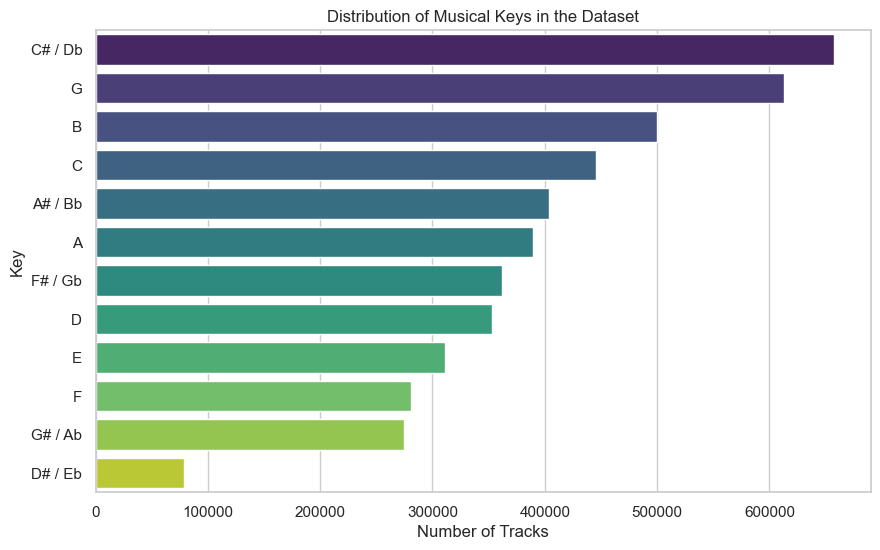

In [32]:
# Count tracks by musical key

key_counts = tracks_key["key_name"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=key_counts.values,
    y=key_counts.index,
    hue=key_counts.index,
    palette="viridis",
    legend=False
)

plt.title("Distribution of Musical Keys in the Dataset")
plt.xlabel("Number of Tracks")
plt.ylabel("Key")

plt.show()

In [33]:
# Compute key distribution by genre

genre_key_distribution = (
    tracks_key
    .groupby(["genre_name", "key_name"])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to proportions
genre_key_distribution = genre_key_distribution.div(
    genre_key_distribution.sum(axis=1),
    axis=0
)

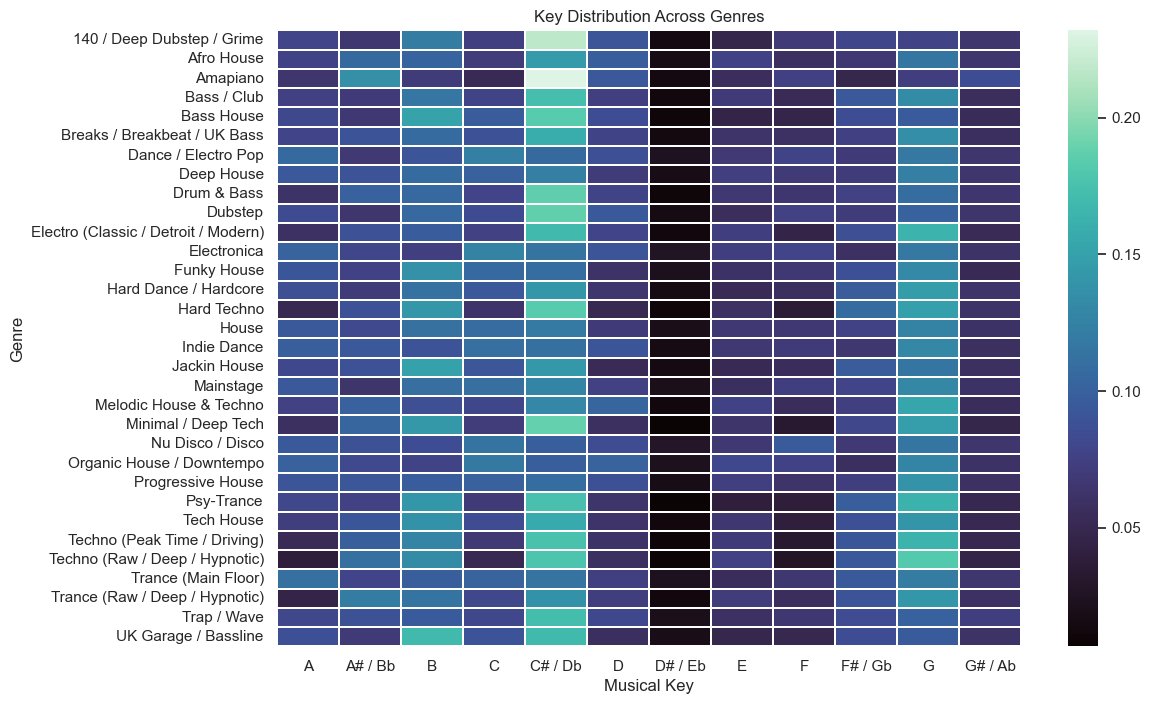

In [34]:
# Visualize key distribution across genres

plt.figure(figsize=(12,8))

sns.heatmap(
    genre_key_distribution,
    cmap="mako",
    linewidths=0.3
)

plt.title("Key Distribution Across Genres")
plt.xlabel("Musical Key")
plt.ylabel("Genre")

plt.show()

### Observations

The distribution of musical keys across genres appears relatively balanced, suggesting that electronic music producers do not strongly favor a single tonal center.

However, some pitch classes appear slightly more frequently across multiple genres. This may reflect common harmonic practices in electronic music production, where certain tonalities are preferred due to synthesizer presets, chord progressions, and harmonic mixing techniques used by DJs.

Overall, the heatmap suggests that harmonic choices are broadly distributed across genres, while rhythmic and energetic characteristics tend to differentiate electronic music styles more strongly.

## Loudness Analysis Across Genres

Another relevant audio feature is **loudness**, which measures the overall intensity of a track in decibels (dB).

Loudness values are averaged across the entire track and typically range between **-60 dB and 0 dB**, with higher values corresponding to louder and more dynamically compressed recordings.

Analyzing loudness across genres can reveal differences in production style, since modern electronic music often relies on compression and limiting to achieve high perceived loudness in club environments.

In [60]:
# Compute average loudness for each genre

genre_loudness = (
    tracks_dataset
    .groupby("genre_name")["loudness"]
    .mean()
    .sort_values(ascending=False)
)

genre_loudness.head(10)

genre_name
Drum & Bass             -5.442977
Hard Dance / Hardcore   -5.616188
Bass House              -6.365797
Dubstep                 -6.474273
Mainstage               -6.608765
Funky House             -6.951527
Hard Techno             -7.301685
UK Garage / Bassline    -7.323992
Psy-Trance              -7.551317
Trance (Main Floor)     -7.839008
Name: loudness, dtype: float64

In [72]:
# Create continuous color palette for loudness plots

loudness_palette = sns.color_palette("rocket", 32)

top_palette = loudness_palette[:16]
bottom_palette = loudness_palette[16:]

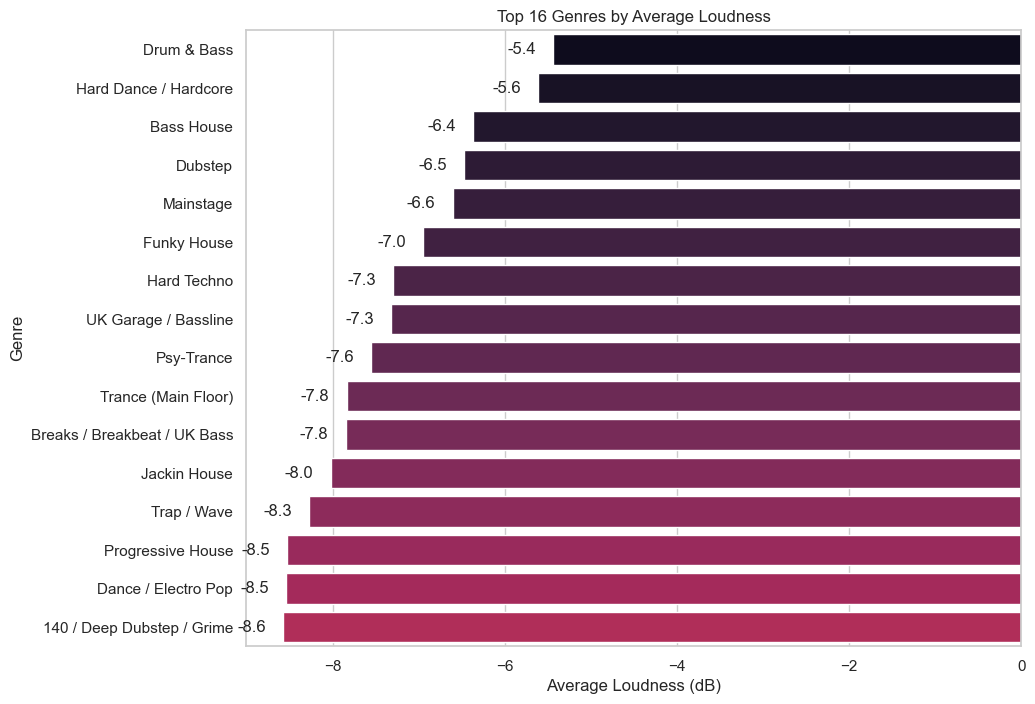

In [80]:
# Select genres with highest average loudness

top_loudness = genre_loudness.head(16)

plt.figure(figsize=(10,8))

ax = sns.barplot(
    x=top_loudness.values,
    y=top_loudness.index,
    hue=top_loudness.index,
    palette=top_palette,
    legend=False
)

plt.title("Top 16 Genres by Average Loudness")
plt.xlabel("Average Loudness (dB)")
plt.ylabel("Genre")

for i, value in enumerate(top_loudness.values):
    ax.text(value - 0.2, i, f"{value:.1f}", va="center", ha="right")

plt.show()

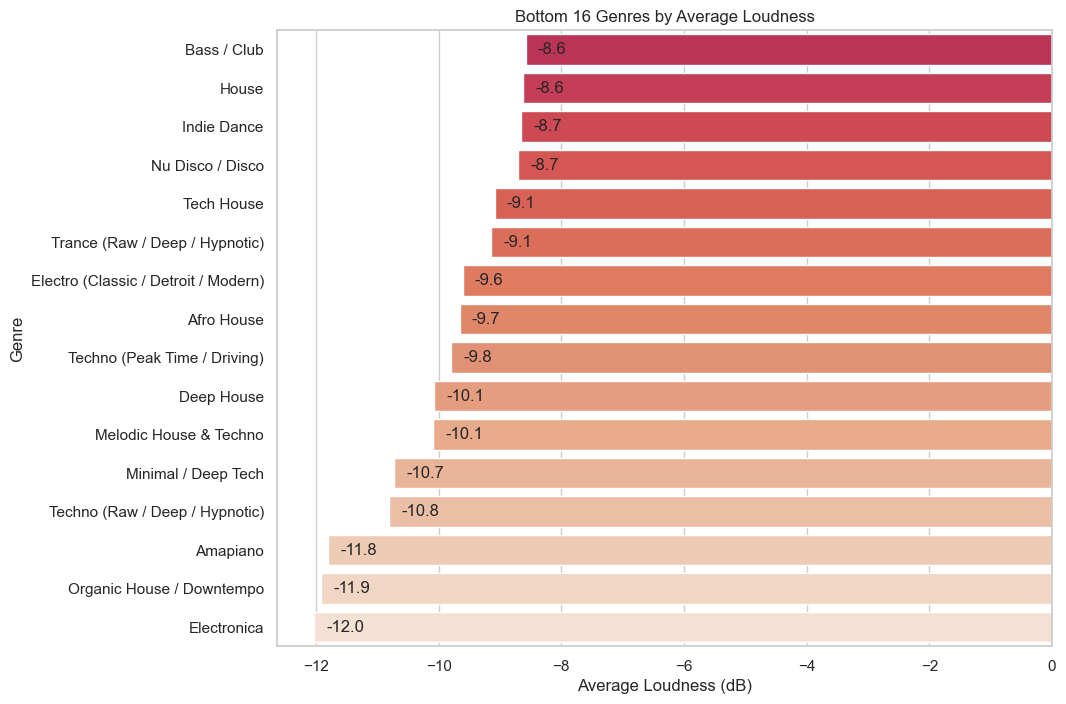

In [86]:
# Select genres with lowest average loudness

bottom_loudness = genre_loudness.tail(16).sort_values(ascending=False)

plt.figure(figsize=(10,8))

ax = sns.barplot(
    x=bottom_loudness.values,
    y=bottom_loudness.index,
    hue=bottom_loudness.index,
    palette=bottom_palette,
    legend=False
)

plt.title("Bottom 16 Genres by Average Loudness")
plt.xlabel("Average Loudness (dB)")
plt.ylabel("Genre")

for i, value in enumerate(bottom_loudness.values):
    ax.text(value + 0.2, i, f"{value:.1f}", va="center")

plt.show()

### Observations

Genres with the highest average loudness tend to correspond to styles associated with strong rhythmic impact and aggressive production techniques.

**Drum & Bass**, **Hard Dance / Hardcore**, and **Bass House** appear among the loudest genres, reflecting the widespread use of compression and limiting in club-oriented electronic music.

Genres with lower average loudness generally correspond to styles with a wider dynamic range, more atmospheric production, or less aggressive sound design.

Overall, loudness provides a complementary perspective to the previously analyzed **energy** feature, capturing differences in production intensity across genres.

## Correlation Analysis of Audio Features

After analyzing genre-level differences, the next step is to examine how audio features relate to each other across the full dataset.

Correlation analysis helps identify:

- features that tend to increase together
- variables with strong inverse relationships
- groups of descriptors that may reflect similar musical characteristics

This provides a broader view of the structure of Spotify audio features in electronic music.

In [92]:
# Compute correlation matrix for main numerical audio features

audio_features_corr = tracks_dataset[
    [
        "acousticness",
        "danceability",
        "energy",
        "instrumentalness",
        "liveness",
        "loudness",
        "speechiness",
        "tempo",
        "valence"
    ]
].corr()

audio_features_corr

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
acousticness,1.000000,-0.392648,-0.521156,-0.041646,-0.019047,-0.467656,0.045699,-0.219618,-0.124843
danceability,-0.392648,1.000000,0.135180,0.048664,-0.155169,0.188419,0.049714,-0.029811,0.326040
energy,-0.521156,0.135180,1.000000,-0.013167,0.138018,0.701231,0.000913,0.276931,0.171888
instrumentalness,-0.041646,0.048664,-0.013167,1.000000,-0.120223,-0.264248,-0.305215,0.061383,-0.204708
liveness,-0.019047,-0.155169,0.138018,-0.120223,1.000000,0.122285,0.116708,0.050358,-0.030635
loudness,-0.467656,0.188419,0.701231,-0.264248,0.122285,1.000000,0.086548,0.221393,0.205943
speechiness,0.045699,0.049714,0.000913,-0.305215,0.116708,0.086548,1.000000,0.037745,0.074846
tempo,-0.219618,-0.029811,0.276931,0.061383,0.050358,0.221393,0.037745,1.000000,-0.014556
valence,-0.124843,0.326040,0.171888,-0.204708,-0.030635,0.205943,0.074846,-0.014556,1.000000


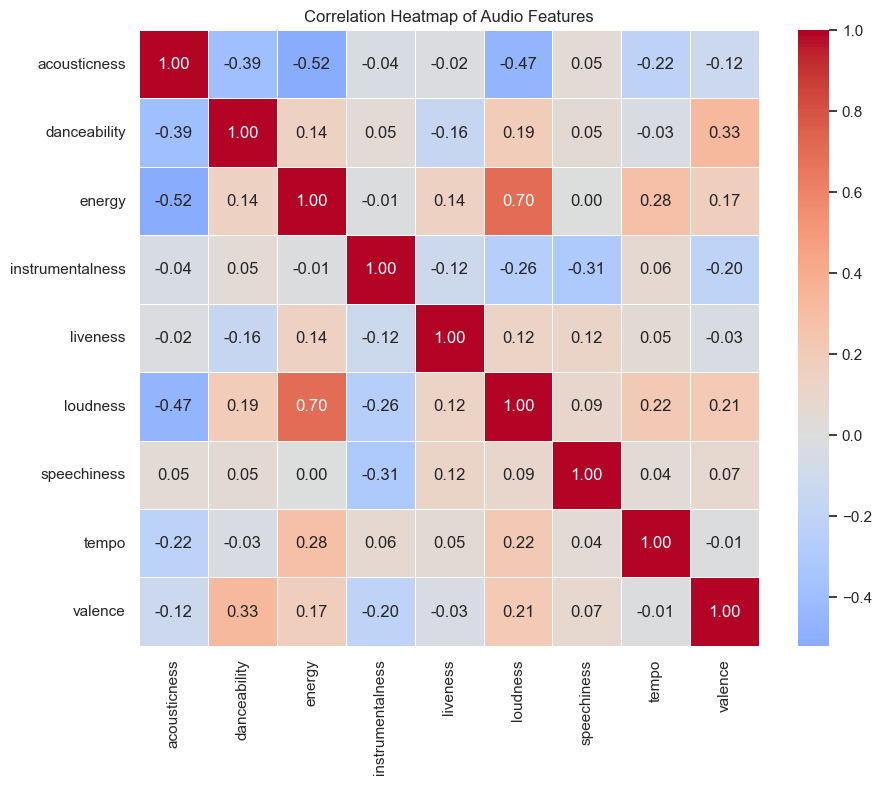

In [94]:
# Visualize correlation matrix

plt.figure(figsize=(10,8))

sns.heatmap(
    audio_features_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Audio Features")
plt.show()

### Observations

The correlation heatmap reveals several meaningful relationships between audio features.

The strongest positive correlation appears between **energy** and **loudness** (0.70), reflecting common production practices in modern electronic music where energetic tracks tend to be heavily compressed and dynamically limited.

A strong negative relationship is observed between **acousticness** and **energy** (-0.52), indicating that tracks with more acoustic characteristics tend to be less intense and electronically produced.

Acousticness also shows a negative correlation with **loudness**, suggesting that more acoustic tracks often preserve a wider dynamic range.

Moderate positive relationships appear between **danceability** and **valence**, indicating that tracks designed for dancing often exhibit more positive or uplifting musical characteristics.

Overall, the correlation structure highlights how rhythmic, energetic, and production-related features interact within electronic music datasets.